In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.tensor([1.0, 2.0]) @ torch.tensor([3.0, 4.0]))


2.10.0+cpu
False
tensor(11.)


In [ ]:
pip install torch

Problem 1

In [1]:
import torch

B,T,C = 2,4,3
x = torch.randn(B,T,C)
y = torch.tensor([
    [1,0,1,1],
    [0,1,1,0]
])

mask = y.unsqueeze(-1) #make the dimensions compatible for broadcasting
masked_x = mask * x #multiply with wherever y ==1
sum = masked_x.sum(dim=1) #sum over the T dimension
count = mask.sum(dim=1)
mean = sum/count
print(mean.shape)
print(mean)


torch.Size([2, 3])
tensor([[ 1.1860,  0.1576,  0.4864],
        [ 0.9591, -1.2537,  0.3277]])


Problem 2


In [3]:
import torch

x = torch.randn(5)
x_shift = x - x.max()
exp_x = torch.exp(x_shift)
softmax = exp_x/exp_x.sum() #softmax implemented manually
torch_softmax = torch.softmax(x,dim=0)
print(softmax)
print(torch_softmax)

tensor([0.5268, 0.0948, 0.1629, 0.1534, 0.0622])
tensor([0.5268, 0.0948, 0.1629, 0.1534, 0.0622])


Original softmax function is defined as e^xi / sum(e^xi) but huge xi values blow up the exponentials hence we fix it by using the shifted value of xi (xi - max(xi)). This would not change the probabilities since it is multiplied in both the numerator as well as the denominator and it prevents overflow.

Problem 3

In [4]:
B,T,d = 2,4,8
Q = torch.randn(B,T,d)
K = torch.randn(B,T,d)

scores1 = torch.einsum('btd,bsd->bts', Q, K)
scores2 = Q@K.transpose(-2,-1) #matmul
print(torch.allclose(scores1,scores2))

True


Problem 4

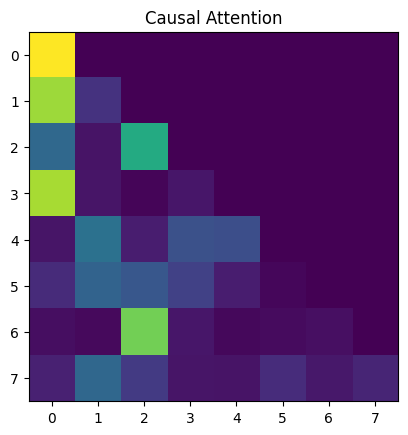

In [6]:
import matplotlib.pyplot as plt
T = 8
scores = torch.randn(T,T) #8x8
mask = torch.triu(torch.ones(T,T),diagonal=1)
mask = mask.masked_fill(mask==1,float('-inf'))
mask = mask.masked_fill(mask==0,0)
masked_scores = scores+mask
attention = torch.softmax(masked_scores,dim=-1)

plt.imshow(attention.detach().numpy())
plt.colorbar
plt.title("Causal Attention")
plt.show()


Problem 5

In [11]:
import torch
B,T,C = 2,4,6
x = torch.randn(B,T,C)
gamma = torch.ones(C)
beta = torch.zeros(C)
eps = 1e-5

x_mean = x.mean(dim=2,keepdim=True) #Not dropping the C dimension
x_var = x.var(dim=2,unbiased=False,keepdim=True)

x_hat = (x-x_mean)/torch.sqrt((x_var+eps)) #normalise
out = gamma*x_hat + beta

ln = torch.nn.LayerNorm(C)
ln.weight.data = gamma
ln.bias.data = beta

torch_out = ln(x)
print(torch.allclose(out,torch_out,atol=1e-5))


True


Problem 6

In [12]:
import torch
x = torch.randn(4, requires_grad=True)
y = (x**2).sum()
y.backward()

print(x)
print(x.grad) #derivative of x^2 which is 2x


tensor([ 0.8449,  1.2689, -0.4144,  0.3438], requires_grad=True)
tensor([ 1.6898,  2.5378, -0.8289,  0.6875])


In [13]:
x = torch.randn(4, requires_grad=True)
y = torch.softmax(x, dim=0).sum()
y.backward()
print(x.grad)

tensor([-3.6142e-08, -2.4627e-08, -1.9234e-08, -3.9207e-08])


softmax(x).sum() = 1 so the derivative of a constant is zero hence the output becomes nearly zero.